In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")


## LODING DATASET 

In [5]:
df = pd.read_csv(r"E:\INFOTACT SOLUTION\Consumer_Shopping_Trends.csv")

df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11789 entries, 0 to 11788
Data columns (total 25 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          11789 non-null  int64  
 1   monthly_income               11789 non-null  int64  
 2   daily_internet_hours         11789 non-null  float64
 3   smartphone_usage_years       11789 non-null  int64  
 4   social_media_hours           11789 non-null  float64
 5   online_payment_trust_score   11789 non-null  int64  
 6   tech_savvy_score             11789 non-null  int64  
 7   monthly_online_orders        11789 non-null  int64  
 8   monthly_store_visits         11789 non-null  int64  
 9   avg_online_spend             11789 non-null  int64  
 10  avg_store_spend              11789 non-null  int64  
 11  discount_sensitivity         11789 non-null  int64  
 12  return_frequency             11789 non-null  int64  
 13  avg_delivery_day

##  Data Cleaning


In [7]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.ffill(inplace=True)
if 'Purchase Date' in df.columns:
    df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

print("Data Cleaned ✅")

Data Cleaned ✅


## KPIs

In [21]:
# Total online spend
total_online_sales = df['avg_online_spend'].sum()

# Average online spend
avg_online_spend = df['avg_online_spend'].mean()

# Total store spend
total_store_sales = df['avg_store_spend'].sum()

# Average store spend
avg_store_spend = df['avg_store_spend'].mean()

print("Total Sales:", total_online_sales)
print("Average Spend:", avg_online_spend)
print("Total Customers:", total_store_sales)


Total Sales: 878928062
Average Spend: 74554.92934091103
Total Customers: 891974988


## Visualization
## 📊 Spending by Category

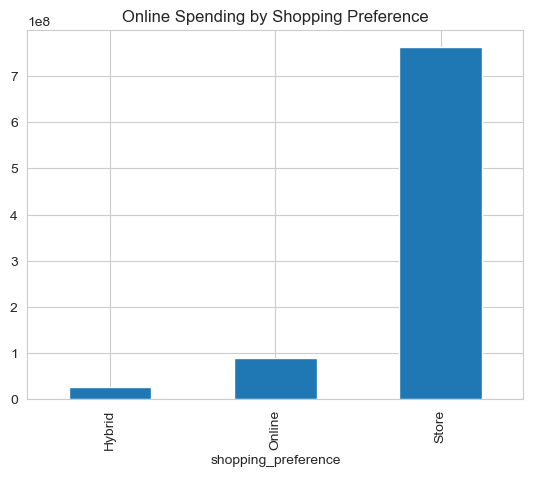

In [24]:
category = df.groupby('shopping_preference')['avg_online_spend'].sum()
category.plot(kind='bar')
plt.title("Online Spending by Shopping Preference")
plt.savefig("Online spending by shopping.png", dpi=300, bbox_inches='tight')


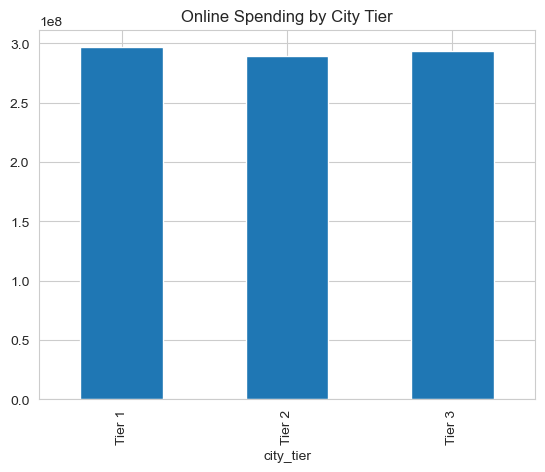

In [25]:
category = df.groupby('city_tier')['avg_online_spend'].sum()
category.plot(kind='bar')
plt.title("Online Spending by City Tier")
plt.savefig("Online spending by city.png", dpi=300, bbox_inches='tight')

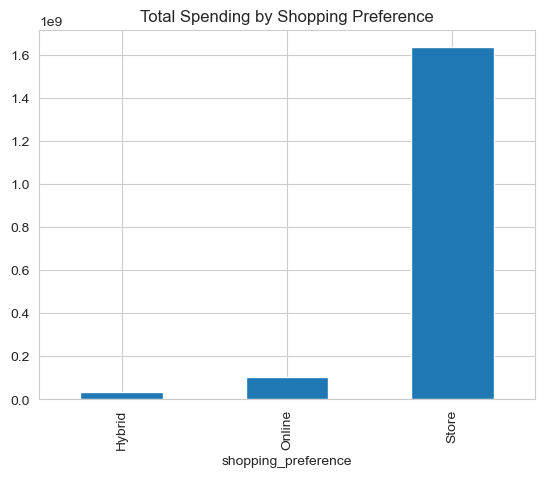

In [26]:
df['total_spend'] = df['avg_online_spend'] + df['avg_store_spend']

category = df.groupby('shopping_preference')['total_spend'].sum()
category.plot(kind='bar')
plt.title("Total Spending by Shopping Preference")
plt.savefig("Total spending_by_preference.png", dpi=300, bbox_inches='tight')


## 📈 Monthly Trend


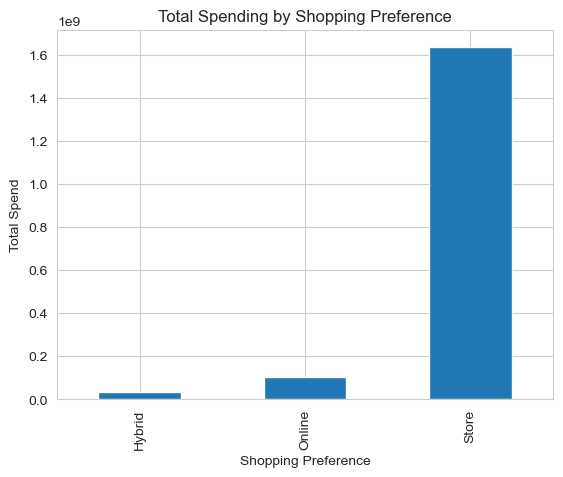

In [27]:
# ✅ Create a total spend column
df['total_spend'] = df['avg_online_spend'] + df['avg_store_spend']

# ✅ Group by shopping preference (instead of missing 'Category')
category = df.groupby('shopping_preference')['total_spend'].sum()

# ✅ Plot spending by shopping preference
category.plot(kind='bar')
plt.title("Total Spending by Shopping Preference")
plt.xlabel("Shopping Preference")
plt.ylabel("Total Spend")
plt.savefig("spending_by_preference.png", dpi=300, bbox_inches='tight')
plt.show()


## 🥧 Payment Method


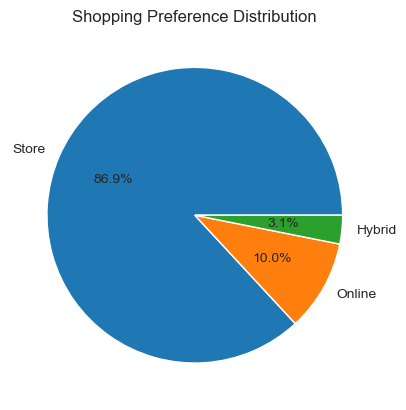

In [28]:
payment = df['shopping_preference'].value_counts()

payment.plot(kind='pie', autopct='%1.1f%%')
plt.title("Shopping Preference Distribution")
plt.ylabel("")  # hides y-label for cleaner pie chart
plt.savefig("shopping_preference_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


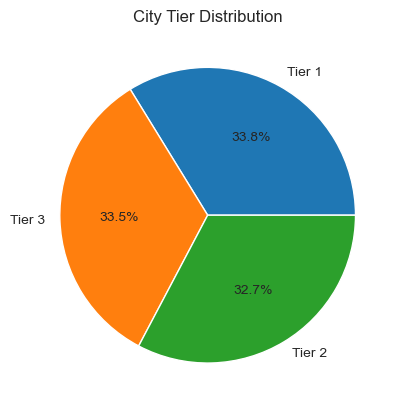

In [30]:
city = df['city_tier'].value_counts()

city.plot(kind='pie', autopct='%1.1f%%')
plt.title("City Tier Distribution")
plt.ylabel("")
plt.savefig("city_distribution.png", dpi=300, bbox_inches='tight')
plt.show()


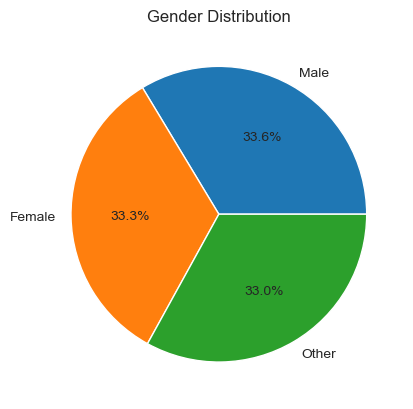

In [29]:
gender = df['gender'].value_counts()

gender.plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.ylabel("")
plt.savefig("Gender Distribution.png", dpi=300, bbox_inches='tight')
plt.show()


## Correlation


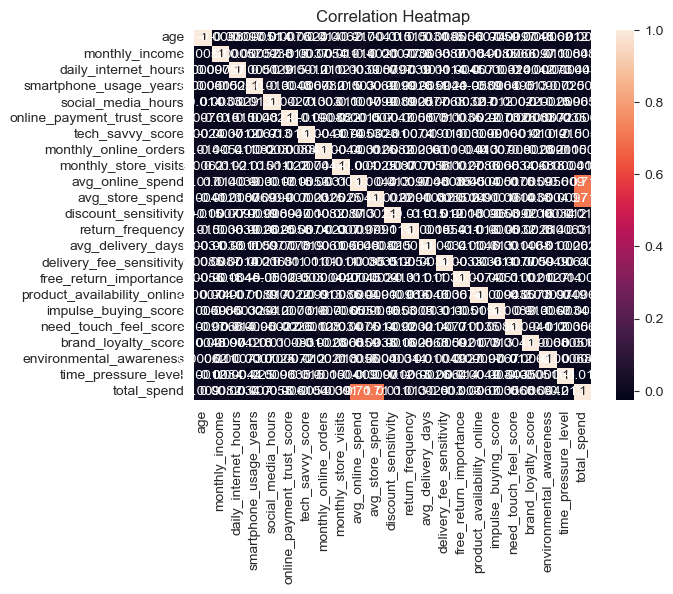

In [32]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()